# 勇者傳說 — Monster V4 Fix Generator (T4 GPU)

Regenerate **9 blacklisted monsters** that V3 failed to produce correctly.

| Monster | V3 Failure | V4 Fix |
|---------|-----------|--------|
| mon_dark_knight | too small / fragment | bigger subject, brighter armor highlights |
| mon_flower | extremely dark, invisible | bright colors, white petal accents |
| mon_ghost | wrong content (octopus) | explicit "floating ghost spirit" |
| mon_insect | wrong content (golem) | explicit "beetle bug insect" |
| mon_knight | too small, indistinct | full-body armored warrior |
| mon_mushroom | red grid artifact | clean mushroom creature |
| mon_slime | wrong content (warrior) | explicit "gel blob slime" |
| mon_wolf_dire | multi-sprite | stronger single-creature negative |
| mon_wolf_ice | multi-sprite, faint | stronger single-creature + brighter |

**Key V4 changes vs V3:**
- Higher guidance scale (8.5) for stronger prompt adherence
- More steps (25) for better detail
- Explicit `ONE single creature` in every prompt
- Stronger negative prompt against multi-sprite / spritesheet
- Subject-specific keywords to avoid wrong-content drift

**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

## 1. Setup

In [6]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0

## 2. Utilities

In [ ]:
class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')

## 3. V4 Prompt Data — Hardened Prompts

Each prompt is carefully rewritten to address the specific V3 failure mode.

In [ ]:
PROMPTS = {
    "_meta": {
        "style_prefix_xl": "16-bit JRPG pixel art sprite, Dragonquest style, ONE single creature only",
        "style_suffix_xl": "centered on transparent background, clean sharp edges, vivid colors, full body visible, detailed pixel art sprite",
        "negative_prompt_xl": "blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, spritesheet, grid, tiled, side-by-side, front-and-back, turnaround, human photo, realistic, 3D render, dark background, black background, too small, tiny, miniature"
    },
    "monsters": [
        {
            "name": "mon_dark_knight",
            "prompt_xl": "imposing dark knight enemy, FULL BODY visible head to boots, pitch-black plate armor with glowing purple runes, tattered dark cape, menacing horned helmet with red visor glow, wielding large cursed greatsword, heavy shoulder pauldrons, undead corrupted warrior",
            "size": 192, "steps_xl": 25, "guidance_xl": 8.5,
            "v3_issue": "too small / fragment"
        },
        {
            "name": "mon_flower",
            "prompt_xl": "dangerous carnivorous flower plant monster, BRIGHT vivid red and green colors, large venus flytrap head with sharp teeth, thick green stem body, thorny vine arms reaching outward, poison dripping petals, bulbous base, fantasy plant creature",
            "size": 192, "steps_xl": 25, "guidance_xl": 8.5,
            "v3_issue": "extremely dark, nearly invisible"
        },
        {
            "name": "mon_ghost",
            "prompt_xl": "floating wispy ghost spirit monster, translucent pale white-blue ethereal body, NO tentacles NO octopus, classic sheet-ghost shape with trailing wisps, hollow dark eye sockets, gaping mouth, spectral glow, haunting floating phantom",
            "size": 192, "steps_xl": 25, "guidance_xl": 9.0,
            "v3_issue": "wrong content (octopus/jellyfish)"
        },
        {
            "name": "mon_insect",
            "prompt_xl": "giant armored BEETLE BUG insect monster, NOT a golem NOT a robot, iridescent dark green chitinous shell, six segmented legs, sharp mandible jaws, compound eyes, antennae, hard wing covers, creepy crawling bug creature",
            "size": 192, "steps_xl": 25, "guidance_xl": 9.0,
            "v3_issue": "wrong content (golem instead of beetle)"
        },
        {
            "name": "mon_knight",
            "prompt_xl": "corrupted armored knight enemy, FULL BODY visible from helmet to greaves, dented rusty iron armor, tattered red surcoat, cracked shield with faded emblem, broken longsword, ghostly pale face visible through open visor, fallen warrior",
            "size": 192, "steps_xl": 25, "guidance_xl": 8.5,
            "v3_issue": "too small, upper half indistinct"
        },
        {
            "name": "mon_mushroom",
            "prompt_xl": "walking mushroom monster creature, large bright red spotted cap like toadstool, cute angry face with beady eyes, stubby legs walking, small arms, white stalk body, spore cloud puffing, forest fungus enemy, vivid saturated colors",
            "size": 192, "steps_xl": 25, "guidance_xl": 8.5,
            "v3_issue": "red grid artifact"
        },
        {
            "name": "mon_slime",
            "prompt_xl": "classic RPG slime monster, NOT a human NOT a warrior, simple cute teardrop-shaped translucent gel blob, bright green gelatinous body, small dot eyes and smile, bouncy jiggly form, shiny surface reflections, iconic JRPG slime creature",
            "size": 192, "steps_xl": 25, "guidance_xl": 9.0,
            "v3_issue": "wrong content (humanoid warrior)"
        },
        {
            "name": "mon_wolf_dire",
            "prompt_xl": "ONE single dire wolf beast monster, massive dark gray wolf standing in profile, glowing fierce amber eyes, battle scars across muzzle, thick bristling fur, muscular haunches, bared fangs snarling, alpha predator, lone wolf",
            "size": 192, "steps_xl": 25, "guidance_xl": 9.0,
            "v3_issue": "multi-sprite (front/back/orb)"
        },
        {
            "name": "mon_wolf_ice",
            "prompt_xl": "ONE single arctic ice wolf beast monster, white fur with frost crystal sparkles, pale ice-blue glowing eyes, cold breath mist from mouth, standing proud, thick winter coat, icicle-tipped tail, lone frost wolf predator, bright vivid coloring",
            "size": 192, "steps_xl": 25, "guidance_xl": 9.0,
            "v3_issue": "multi-sprite, faint silhouette"
        }
    ]
}

print(f'V4 targets: {len(PROMPTS["monsters"])} monsters')
for m in PROMPTS['monsters']:
    print(f"  {m['name']:22s} — fix: {m['v3_issue']}")

## 4. Load SDXL Pipeline + LoRA

In [7]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'

# Check if cached model is valid (not corrupted meta tensors)
use_cache = False
if (sdxl_cache / 'model_index.json').exists():
    # Verify at least one safetensors file has real data (not 0 bytes)
    st_files = list(sdxl_cache.rglob('*.safetensors'))
    if st_files and all(f.stat().st_size > 1000 for f in st_files[:3]):
        use_cache = True
    else:
        print(f'[pipeline] Cache appears corrupted, downloading fresh...')

model_path = str(sdxl_cache) if use_cache else SDXL_HUB

print(f'[pipeline] Loading SDXL from {"cache" if use_cache else "HuggingFace Hub"} ({DEVICE})...')
t0 = time.time()

# Load directly to target device to avoid meta tensor issues with .to()
kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

try:
    pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs).to(DEVICE)
except (NotImplementedError, RuntimeError) as e:
    if 'meta tensor' in str(e).lower() or 'Cannot copy out of meta tensor' in str(e):
        print(f'[pipeline] Cached model has meta tensors, deleting cache and reloading...')
        import shutil
        if sdxl_cache.exists():
            shutil.rmtree(sdxl_cache)
        pipe = StableDiffusionXLPipeline.from_pretrained(
            SDXL_HUB, **kwargs
        ).to(DEVICE)
    else:
        raise

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

# LoRA weight 0.85 (slightly higher than V2's 0.8 for stronger pixel art style)
try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.85])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.85)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe.enable_attention_slicing()

# Cache to Drive for future runs (skip if loading from cache already)
if not use_cache and ON_COLAB:
    try:
        sdxl_cache.mkdir(parents=True, exist_ok=True)
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception as e:
        print(f'[warn] Cache save failed: {e}')

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

[pipeline] Loading SDXL from cache (cuda)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Some weights of the model checkpoint at /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0/unet were not used when initializing UNet2DConditionModel: 
 ['down_blocks.2.attentions.1.transformer_blocks.8.attn2.to_k.lora_A.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.6.attn2.to_out.0.lora_B.pixel_xl.weight, down_blocks.2.attentions.0.transformer_blocks.4.attn1.to_out.0.lora_A.pixel_xl.weight, up_blocks.0.attentions.2.transformer_blocks.0.attn2.to_k.base_layer.weight, down_blocks.2.attentions.0.transformer_blocks.0.attn2.to_v.lora_B.pixel_xl.weight, down_blocks.1.attentions.1.transformer_blocks.0.attn1.to_out.0.lora_B.pixel_xl.weight, down_blocks.2.attentions.0.transformer_blocks.8.attn1.to_v.base_layer.weight, up_blocks.1.attentions.0.transformer_blocks.1.attn2.to_v.lora_B.pixel_xl.weight, mid_block.attentions.0.transformer_blocks.6.attn1.to_v.lora_A.pixel_xl.weight, up_blocks.0.attentions.1.transformer_blocks.1.attn2.to_k.lora_A.pixel_xl.weight, up_block

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.85)
[pipeline] Ready in 303.8s
[vram] 8.3/14.6 GB


## 5. Background Removal + Post-Processing

In [8]:
from PIL import Image
import numpy as np

_rembg_session = None

def remove_background(img):
    """Remove background using rembg."""
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def build_prompt(entry, meta):
    """Build full prompt and negative prompt."""
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_xl', '')
    neg = meta.get('negative_prompt_xl', '')
    body = entry.get('prompt_xl', '')
    prompt = f'{prefix}, {body}, {suffix}'
    return prompt, neg


def postprocess(img, target_size):
    """Remove background, crop, resize to target size with bottom-align."""
    img = remove_background(img.convert('RGBA'))

    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return img.resize((target_size, target_size), Image.NEAREST)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    cw, ch = cropped.size
    scale = min(target_size / cw, target_size / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    canvas = Image.new('RGBA', (target_size, target_size), (0, 0, 0, 0))
    x = (target_size - new_w) // 2
    y = target_size - new_h
    canvas.paste(resized, (x, y))
    return canvas


def quality_check(img_path, min_opaque_pct=8.0, min_size_pct=15.0):
    """Check if generated image passes quality gate.
    Returns (pass, reason) tuple."""
    img = Image.open(img_path).convert('RGBA')
    arr = np.array(img)
    alpha = arr[:, :, 3]
    total = alpha.size
    opaque = np.sum(alpha > 10)
    opaque_pct = 100.0 * opaque / total

    if opaque_pct < min_opaque_pct:
        return False, f'too transparent ({opaque_pct:.1f}% opaque, need {min_opaque_pct}%)'

    # Check content fills enough of the canvas
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if rows.any() and cols.any():
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        bbox_h = rmax - rmin + 1
        bbox_w = cmax - cmin + 1
        h, w = alpha.shape
        size_pct = 100.0 * max(bbox_h / h, bbox_w / w)
        if size_pct < min_size_pct:
            return False, f'content too small ({size_pct:.0f}% of canvas, need {min_size_pct}%)'

    return True, 'ok'

print('Post-processing ready')

Post-processing ready


## 6. Test: Generate 1 Sprite (mon_slime)

Test with the hardest case — slime kept generating as a warrior.

Token indices sequence length is longer than the specified maximum sequence length for this model (90 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['clean sharp edges, vivid colors, full body visible, detailed pixel art sprite']


Prompt: 16-bit JRPG pixel art sprite, Dragonquest style, ONE single creature only, classic RPG slime monster, NOT a human NOT a ...
Negative: blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, spritesheet, grid, t...
Steps: 25, Guidance: 9.0


Token indices sequence length is longer than the specified maximum sequence length for this model (90 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['clean sharp edges, vivid colors, full body visible, detailed pixel art sprite']


  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Raw output:


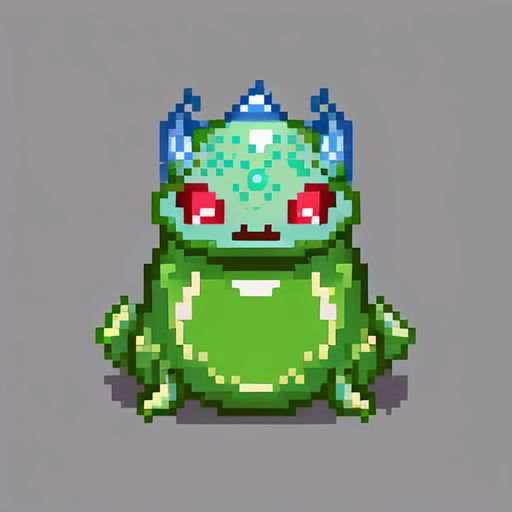

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

After postprocess (192px):


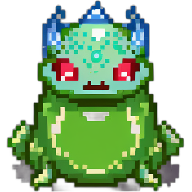

In [9]:
from IPython.display import display

meta = PROMPTS['_meta']
# Pick slime as test (worst offender — generated warrior in V3)
test_entry = next(e for e in PROMPTS['monsters'] if e['name'] == 'mon_slime')

prompt, neg = build_prompt(test_entry, meta)
print(f'Prompt: {prompt[:120]}...')
print(f'Negative: {neg[:100]}...')
print(f'Steps: {test_entry["steps_xl"]}, Guidance: {test_entry["guidance_xl"]}')

result = pipe(
    prompt=prompt, negative_prompt=neg,
    width=512, height=512,
    num_inference_steps=test_entry['steps_xl'],
    guidance_scale=test_entry['guidance_xl'],
)
print('Raw output:')
display(result.images[0])

test_img = postprocess(result.images[0], test_entry['size'])
print(f'After postprocess ({test_entry["size"]}px):')
display(test_img)
free_vram()

## 7. Generate All 9 Monsters

Each monster gets **up to 3 attempts**. If first attempt fails quality check,
retry with a different seed. This handles the stochastic nature of SD —
sometimes the same prompt produces good/bad results randomly.

~8-10s per attempt on T4, so worst case ~4.5 min for all 9.

In [10]:
MAX_ATTEMPTS = 3

entries = PROMPTS['monsters']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'monsters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('monsters_v4', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'V4 Monsters: {len(entries)} total, {remaining} to generate\n')

results = []
for i, entry in enumerate(entries):
    name = entry['name']
    out_path = out_dir / f'{name}.png'
    target_size = entry.get('size', 192)
    steps = entry.get('steps_xl', 25)
    guidance = entry.get('guidance_xl', 8.5)

    if tracker.is_done(name) and out_path.exists():
        print(f'[{i+1}/{len(entries)}] [skip] {name}')
        results.append((name, 'skip', ''))
        continue

    prompt, neg = build_prompt(entry, meta)
    success = False

    for attempt in range(1, MAX_ATTEMPTS + 1):
        print(f'[{i+1}/{len(entries)}] {name} (attempt {attempt}/{MAX_ATTEMPTS}, {steps} steps, cfg {guidance})...', end=' ')
        t0 = time.time()

        # Use different seed per attempt for variety
        generator = torch.Generator(device=DEVICE).manual_seed(42 + attempt * 1000 + i)

        result = pipe(
            prompt=prompt, negative_prompt=neg,
            width=512, height=512,
            num_inference_steps=steps,
            guidance_scale=guidance,
            generator=generator,
        )
        img = postprocess(result.images[0], target_size)
        img.save(str(out_path), 'PNG')

        kb = out_path.stat().st_size / 1024
        elapsed = time.time() - t0

        # Quality check
        passed, reason = quality_check(out_path)
        if passed:
            print(f'{kb:.0f} KB, {elapsed:.1f}s ✓')
            tracker.mark_done(name)
            results.append((name, 'ok', f'{kb:.0f}KB, attempt {attempt}'))
            success = True
            break
        else:
            print(f'{kb:.0f} KB, {elapsed:.1f}s ✗ {reason}')
            if attempt < MAX_ATTEMPTS:
                print(f'         Retrying with different seed...')

        free_vram()

    if not success:
        # Keep the last attempt anyway (manual review)
        tracker.mark_done(name)
        results.append((name, 'WARN', f'failed QC after {MAX_ATTEMPTS} attempts'))
        print(f'         ⚠ Keeping last attempt for manual review')

    free_vram()

print(f'\n{"="*60}')
print('V4 Generation Summary:')
for name, status, detail in results:
    icon = '✓' if status == 'ok' else ('⟳' if status == 'skip' else '⚠')
    print(f'  {icon} {name:22s} {status:6s} {detail}')
print(f'{"="*60}')

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['transparent background, clean sharp edges, vivid colors, full body visible, detailed pixel art sprite']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['transparent background, clean sharp edges, vivid colors, full body visible, detailed pixel art sprite']


V4 Monsters: 9 total, 9 to generate

[1/9] mon_dark_knight (attempt 1/3, 25 steps, cfg 8.5)... 

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


46 KB, 21.0s ✓


...

36 KB, 12.0s ✓


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['sharp edges, vivid colors, full body visible, detailed pixel art sprite']
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['sharp edges, vivid colors, full body visible, detailed pixel art sprite']


[9/9] mon_wolf_ice (attempt 1/3, 25 steps, cfg 9.0)... 

  0%|          | 0/25 [00:00<?, ?it/s]

39 KB, 11.9s ✓

V4 Generation Summary:
  ✓ mon_dark_knight        ok     46KB, attempt 1
  ✓ mon_flower             ok     50KB, attempt 1
  ✓ mon_ghost              ok     33KB, attempt 1
  ✓ mon_insect             ok     39KB, attempt 1
  ✓ mon_knight             ok     34KB, attempt 1
  ✓ mon_mushroom           ok     33KB, attempt 1
  ✓ mon_slime              ok     37KB, attempt 1
  ✓ mon_wolf_dire          ok     36KB, attempt 1
  ✓ mon_wolf_ice           ok     39KB, attempt 1


## 8. Quality Review Grid

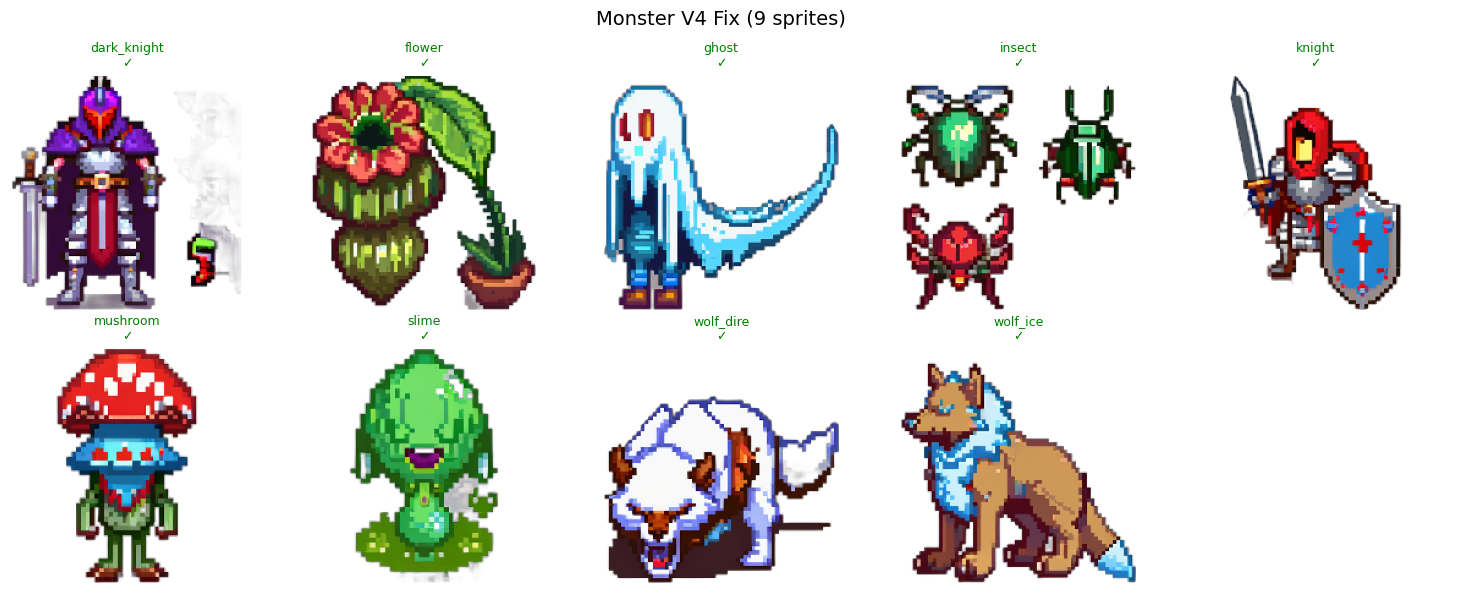

In [ ]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'monsters'
target_names = [e['name'] for e in PROMPTS['monsters']]
pngs = [out_dir / f'{n}.png' for n in target_names if (out_dir / f'{n}.png').exists()]

cols = 5
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
if rows == 1:
    axes = [axes]
for row in axes:
    if not hasattr(row, '__iter__'):
        row = [row]
    for ax in row:
        ax.axis('off')

for i, png in enumerate(pngs):
    r, c = i // cols, i % cols
    ax = axes[r][c] if hasattr(axes[r], '__iter__') else axes[r]
    img = Image.open(png)
    ax.imshow(img)
    passed, reason = quality_check(png)
    status = '✓' if passed else f'✗ {reason[:30]}'
    ax.set_title(f'{png.stem.replace("mon_", "")}\n{status}', fontsize=9,
                 color='green' if passed else 'red')

plt.suptitle(f'Monster V4 Fix ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Generate Manifest + Download Zip

In [ ]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'monsters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['monsters'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/monsters_v4_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

## 10. After Download

```bash
# 1. Copy zip to notebooks/
cp ~/Downloads/monsters_v4_output.zip notebooks/

# 2. Import into game
bash scripts/import_colab_assets.sh notebooks/monsters_v4_output.zip

# 3. Validate
python scripts/validate_colab_assets.py

# 4. Clear blacklist entries in MonsterRenderer.ts for any that pass
# 5. Restart dev server and verify in-game
```